# Cheddar-Logic: Bankroll Risk Analysis

**Risk Manager Simulation** — grounded in actual system parameters from this codebase:

| Parameter | Source | Value |
|---|---|---|
| Min edge (NHL shots) | `run_nhl_player_shots_model.js:240` | `prob_edge_pp >= 0.02` (2pp) |
| Min edge (MLB F5 ML) | `mlb-model.js:696` | `LEAN_EDGE_MIN = 0.04` (4pp) |
| Min edge (MLB totals) | `mlb-model.js:580` | `MLB_F5_EDGE_THRESHOLD = 0.5 runs` |
| Staking target | `WI-0819` | Quarter-Kelly (planned) |
| Daily bet volume | Scheduler cadence | 3–8 bets/day across sports |

Tasks performed:
1. Simulate bankroll over time with variance (Monte Carlo)
2. Compute max drawdown and risk of ruin
3. Stress test worst 5% scenarios
4. Evaluate sensitivity to edge degradation
5. Assess whether system is robust or fragile

## 1. Import Required Libraries

In [1]:
%pip install -q matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings("ignore")
rng = np.random.default_rng(42)

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

print("Libraries loaded ✓")


Libraries loaded ✓


## 2. Define Strategy Parameters

Parameters are anchored to real values from the codebase:

- **Edge (p_edge)**: 2–4 pp above breakeven. `LEAN_EDGE_MIN = 0.04`, NHL shots threshold `0.02`. Base case uses **3pp** edge.
- **Market odds**: Standard -110 juice → breakeven at 52.38%. Occasionally -115 on sharp-side props.
- **Staking**: Quarter-Kelly (WI-0819 target). Full Kelly and 1-unit flat also compared.
- **Volume**: 5 bets/day × 180 active days = **900 bets** per season.
- **Starting bankroll**: 100 units (normalised).
- **Ruin threshold**: 20% of starting bankroll (20 units).

In [3]:
# ── Market parameters ────────────────────────────────────────────────────────
AMERICAN_ODDS    = -110          # typical juice on totals / player props
DECIMAL_ODDS     = 1 + 100 / abs(AMERICAN_ODDS)   # 1.909…
BREAKEVEN_P      = abs(AMERICAN_ODDS) / (abs(AMERICAN_ODDS) + 100)  # 0.5238

# ── Edge scenarios ────────────────────────────────────────────────────────────
# From codebase:
#   NHL shots PLAY threshold: prob_edge_pp >= 0.02  (2 percentage points)
#   MLB F5 ML LEAN_EDGE_MIN : 0.04                  (4 pp)
#   Base case: 3pp edge (midpoint, conservative)
BASE_EDGE_PP     = 0.03          # 3 percentage-point edge
BASE_WIN_P       = BREAKEVEN_P + BASE_EDGE_PP   # ~0.5538

# ── Kelly fraction ────────────────────────────────────────────────────────────
# f* = (b*p - q) / b   where b = decimal_odds - 1
b          = DECIMAL_ODDS - 1   # net odds ratio ≈ 0.909
p          = BASE_WIN_P
q          = 1 - p
FULL_KELLY = (b * p - q) / b    # ≈ 0.057
QUARTER_KELLY = FULL_KELLY / 4  # WI-0819 target ≈ 0.014
FLAT_UNIT     = 0.01            # 1% flat stake as comparison

# ── Simulation parameters ─────────────────────────────────────────────────────
N_BETS         = 900            # ~5 bets/day × 180 active season days
N_SIMS         = 10_000         # Monte Carlo paths
STARTING_BR    = 100.0          # units (normalised)
RUIN_THRESHOLD = 0.20           # ruin = bankroll < 20% of start

print(f"Breakeven probability : {BREAKEVEN_P:.4f} ({BREAKEVEN_P*100:.2f}%)")
print(f"Base win probability  : {BASE_WIN_P:.4f} ({BASE_WIN_P*100:.2f}%)")
print(f"Full Kelly fraction   : {FULL_KELLY:.4f} ({FULL_KELLY*100:.2f}% of bankroll)")
print(f"Quarter-Kelly fraction: {QUARTER_KELLY:.4f} ({QUARTER_KELLY*100:.2f}% of bankroll)")
print(f"Flat stake (1 unit)   : {FLAT_UNIT:.4f} ({FLAT_UNIT*100:.2f}% of bankroll)")
print(f"\nN bets: {N_BETS} | N simulations: {N_SIMS:,} | Ruin <= {RUIN_THRESHOLD*100:.0f}% of start")


Breakeven probability : 0.5238 (52.38%)
Base win probability  : 0.5538 (55.38%)
Full Kelly fraction   : 0.0630 (6.30% of bankroll)
Quarter-Kelly fraction: 0.0158 (1.58% of bankroll)
Flat stake (1 unit)   : 0.0100 (1.00% of bankroll)

N bets: 900 | N simulations: 10,000 | Ruin <= 20% of start


## 3. Simulate Bankroll Over Time with Variance

Monte Carlo across 10,000 paths. Three staking regimes compared side-by-side: flat 1%, full Kelly, and quarter-Kelly (WI-0819 target).

Running simulations …
Done — 10,000 paths × 900 bets each


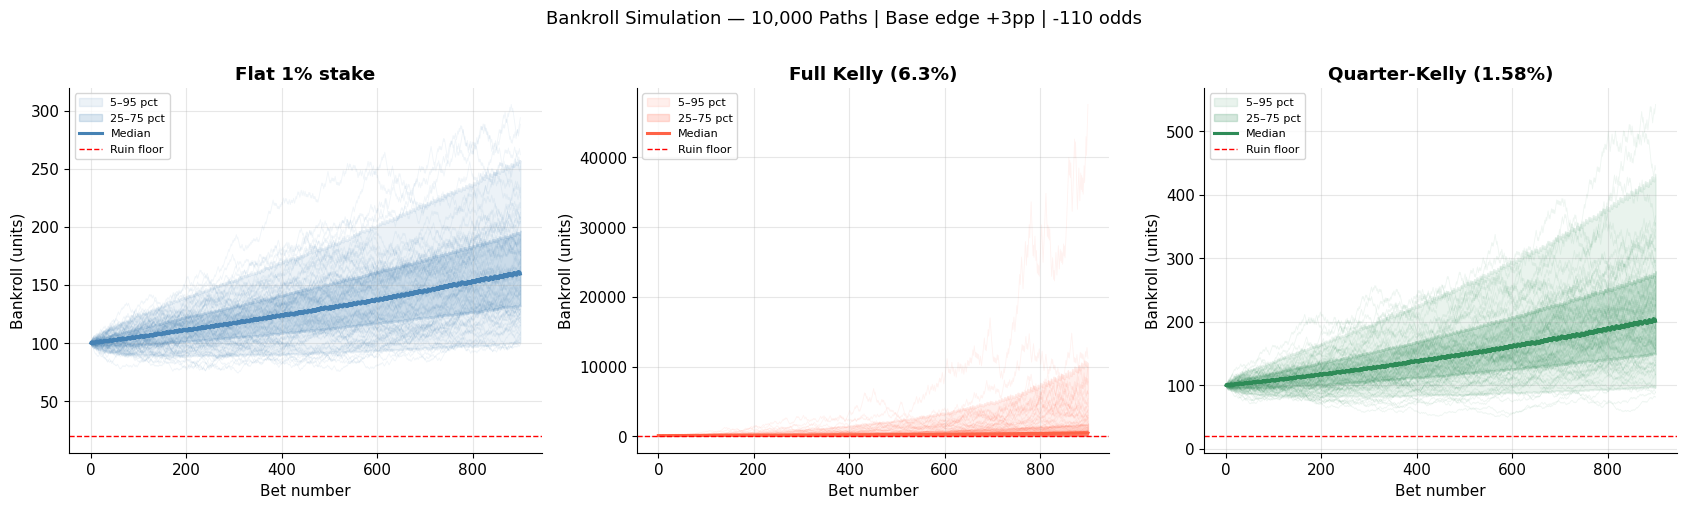


Flat 1%:
  Median final BR : 159.5 units  (+59.5%)
  Mean final BR   : 167.2 units
  5th pct final   : 100.8 units
  95th pct final  : 257.0 units

Full Kelly:
  Median final BR : 483.6 units  (+383.6%)
  Mean final BR   : 2810.7 units
  5th pct final   : 20.0 units
  95th pct final  : 9900.2 units

Quarter-Kelly:
  Median final BR : 201.0 units  (+101.0%)
  Mean final BR   : 225.0 units
  5th pct final   : 97.6 units
  95th pct final  : 426.4 units


In [4]:
def simulate_bankrolls(win_p, stake_fn, n_bets=N_BETS, n_sims=N_SIMS,
                       start=STARTING_BR, ruin_floor=RUIN_THRESHOLD, seed=42):
    """
    Vectorised Monte Carlo bankroll simulation.

    stake_fn(bankroll) -> bet size in units
    Returns array of shape (n_sims, n_bets+1) — full path including start.
    """
    rng_local = np.random.default_rng(seed)
    paths = np.empty((n_sims, n_bets + 1))
    paths[:, 0] = start

    for t in range(n_bets):
        br = paths[:, t].copy()
        # Floor at ruin level — no further betting once ruined
        active = br > start * ruin_floor
        stake = np.where(active, np.array([stake_fn(b) for b in br]), 0.0)
        wins  = rng_local.random(n_sims) < win_p
        delta = np.where(wins, stake * (DECIMAL_ODDS - 1), -stake)
        paths[:, t + 1] = np.maximum(br + delta, start * ruin_floor)

    return paths


# ── Stake functions ───────────────────────────────────────────────────────────
def flat_stake(br):      return br * FLAT_UNIT
def full_kelly(br):      return br * FULL_KELLY
def quarter_kelly(br):   return br * QUARTER_KELLY


print("Running simulations …")
paths_flat  = simulate_bankrolls(BASE_WIN_P, flat_stake,    seed=10)
paths_full  = simulate_bankrolls(BASE_WIN_P, full_kelly,    seed=20)
paths_qk    = simulate_bankrolls(BASE_WIN_P, quarter_kelly, seed=30)
print(f"Done — {N_SIMS:,} paths × {N_BETS} bets each")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=False)
configs = [
    (paths_flat, f"Flat 1% stake", "steelblue"),
    (paths_full, f"Full Kelly ({FULL_KELLY*100:.1f}%)", "tomato"),
    (paths_qk,   f"Quarter-Kelly ({QUARTER_KELLY*100:.2f}%)", "seagreen"),
]
sample_idx = rng.integers(0, N_SIMS, 80)
bet_axis   = np.arange(N_BETS + 1)

for ax, (paths, title, color) in zip(axes, configs):
    # Sample paths
    for i in sample_idx:
        ax.plot(bet_axis, paths[i], color=color, alpha=0.08, lw=0.6)
    # Percentile ribbons
    p5  = np.percentile(paths, 5,  axis=0)
    p25 = np.percentile(paths, 25, axis=0)
    p50 = np.percentile(paths, 50, axis=0)
    p75 = np.percentile(paths, 75, axis=0)
    p95 = np.percentile(paths, 95, axis=0)
    ax.fill_between(bet_axis, p5,  p95, color=color, alpha=0.10, label="5–95 pct")
    ax.fill_between(bet_axis, p25, p75, color=color, alpha=0.20, label="25–75 pct")
    ax.plot(bet_axis, p50, color=color, lw=2.2, label="Median")
    ax.axhline(STARTING_BR * RUIN_THRESHOLD, color="red", lw=1, ls="--", label="Ruin floor")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Bet number")
    ax.set_ylabel("Bankroll (units)")
    ax.legend(fontsize=8)

fig.suptitle("Bankroll Simulation — 10,000 Paths | Base edge +3pp | -110 odds", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── Summary stats ─────────────────────────────────────────────────────────────
for name, paths in [("Flat 1%", paths_flat), ("Full Kelly", paths_full), ("Quarter-Kelly", paths_qk)]:
    final = paths[:, -1]
    print(f"\n{name}:")
    print(f"  Median final BR : {np.median(final):.1f} units  ({(np.median(final)/STARTING_BR - 1)*100:+.1f}%)")
    print(f"  Mean final BR   : {np.mean(final):.1f} units")
    print(f"  5th pct final   : {np.percentile(final, 5):.1f} units")
    print(f"  95th pct final  : {np.percentile(final, 95):.1f} units")


## 4. Compute Maximum Drawdown

For each simulation path: $\text{MDD} = \max_{t} \frac{\text{Peak}(t) - \text{Trough}(t)}{\text{Peak}(t)}$

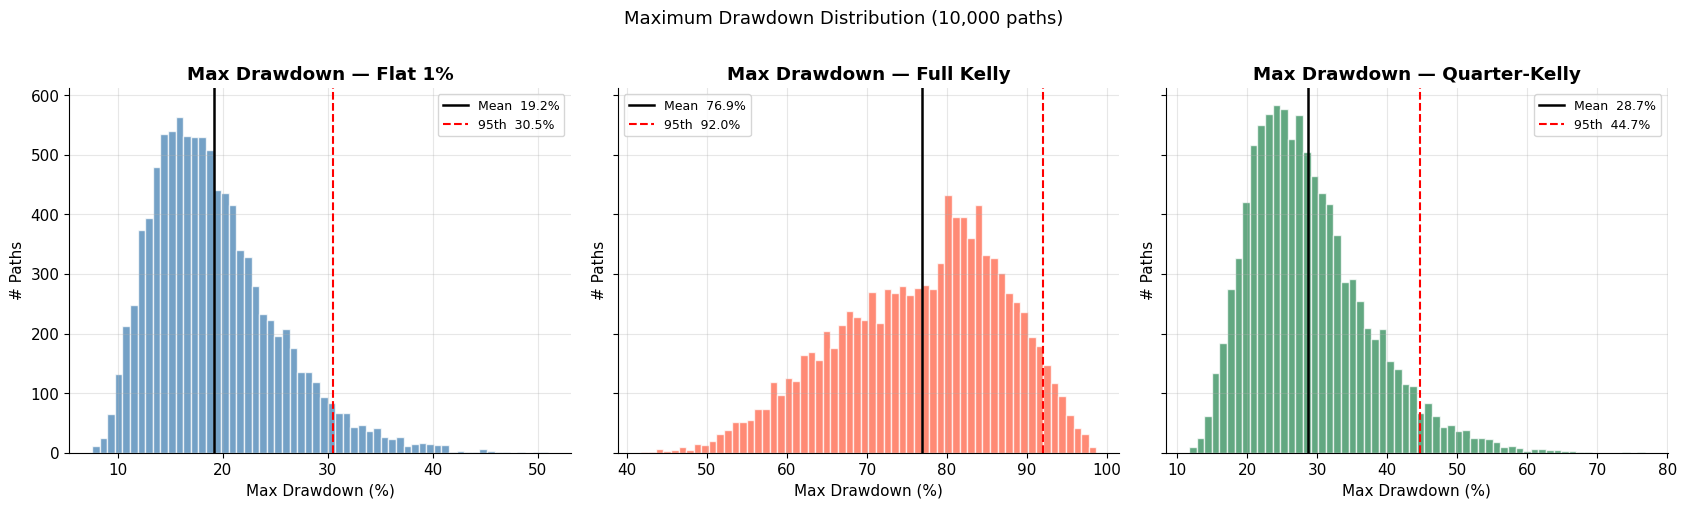


Staking              Mean MDD   Median MDD   95th pct MDD
--------------------------------------------------------
Flat 1%                 19.2%        18.2%           30.5%
Full Kelly              76.9%        78.4%           92.0%
Quarter-Kelly           28.7%        27.4%           44.7%


In [5]:
def max_drawdown_paths(paths):
    """
    Vectorised MDD computation.
    paths: (n_sims, n_bets+1)
    Returns array of shape (n_sims,) with MDD as a fraction [0, 1].
    """
    n_sims = paths.shape[0]
    mdd = np.zeros(n_sims)
    for i in range(n_sims):
        p    = paths[i]
        peak = np.maximum.accumulate(p)
        dd   = (peak - p) / peak
        mdd[i] = dd.max()
    return mdd


mdd_flat = max_drawdown_paths(paths_flat)
mdd_full = max_drawdown_paths(paths_full)
mdd_qk   = max_drawdown_paths(paths_qk)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
for ax, (mdd, title, color) in zip(axes, [
    (mdd_flat, "Flat 1%",     "steelblue"),
    (mdd_full, "Full Kelly",  "tomato"),
    (mdd_qk,   "Quarter-Kelly", "seagreen"),
]):
    ax.hist(mdd * 100, bins=60, color=color, alpha=0.75, edgecolor="white")
    ax.axvline(np.mean(mdd) * 100,          color="black",  lw=1.8, ls="-",  label=f"Mean  {np.mean(mdd)*100:.1f}%")
    ax.axvline(np.percentile(mdd, 95) * 100, color="red",   lw=1.5, ls="--", label=f"95th  {np.percentile(mdd, 95)*100:.1f}%")
    ax.set_title(f"Max Drawdown — {title}", fontweight="bold")
    ax.set_xlabel("Max Drawdown (%)")
    ax.set_ylabel("# Paths")
    ax.legend(fontsize=9)

fig.suptitle("Maximum Drawdown Distribution (10,000 paths)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"\n{'Staking':<18} {'Mean MDD':>10} {'Median MDD':>12} {'95th pct MDD':>14}")
print("-" * 56)
for name, mdd in [("Flat 1%", mdd_flat), ("Full Kelly", mdd_full), ("Quarter-Kelly", mdd_qk)]:
    print(f"{name:<18} {np.mean(mdd)*100:>9.1f}%  {np.median(mdd)*100:>10.1f}%   {np.percentile(mdd, 95)*100:>12.1f}%")


## 5. Compute Risk of Ruin

Empirical (Monte Carlo) vs. analytical approximation.

**Analytical (continuous Kelly):**
$$R \approx \left(\frac{q}{p}\right)^{B / f^*}$$

where $B$ = bankroll, $f^*$ = Kelly stake, $p$ = win prob, $q = 1-p$.

Flat 1%             empirical touch-ruin= 0.00%  permanent-ruin= 0.00%  analytical≈ 0.00%
Full Kelly          empirical touch-ruin=13.89%  permanent-ruin=13.89%  analytical≈ 3.24%
Quarter-Kelly       empirical touch-ruin= 0.00%  permanent-ruin= 0.00%  analytical≈ 0.00%


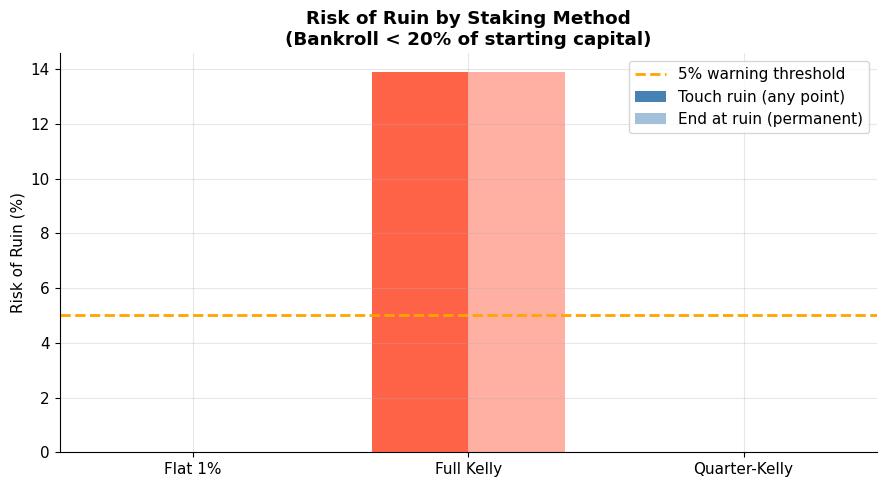

In [6]:
def empirical_ruin(paths, start=STARTING_BR, floor=RUIN_THRESHOLD):
    """Fraction of paths that touched the ruin floor at any point."""
    ruin_level = start * floor
    return np.mean(np.any(paths <= ruin_level + 1e-9, axis=1))

# Also count paths that end at ruin (permanent ruin)
def permanent_ruin(paths, start=STARTING_BR, floor=RUIN_THRESHOLD):
    return np.mean(paths[:, -1] <= start * floor + 1e-9)

# Analytical approximation (works best for proportional kelly stake)
def analytical_ruin(p, q, stake_frac, bankroll_units=1.0, ruin_frac=RUIN_THRESHOLD):
    """Gambler's ruin approximation for proportional betting."""
    if stake_frac <= 0 or p <= q:
        return 1.0
    ratio = q / p
    # Number of "bets" to ruin using fixed-fraction approximation
    n_to_ruin = np.log(ruin_frac) / np.log(1 - stake_frac + stake_frac * b)
    # For Kelly: R ≈ (q/p)^(BR / f) simplified
    r = ratio ** (1.0 / stake_frac)
    return min(r, 1.0)


results_ruin = {}
for label, paths, stake_frac in [
    ("Flat 1%",      paths_flat, FLAT_UNIT),
    ("Full Kelly",   paths_full, FULL_KELLY),
    ("Quarter-Kelly",paths_qk,   QUARTER_KELLY),
]:
    emp  = empirical_ruin(paths)
    perm = permanent_ruin(paths)
    anl  = analytical_ruin(p, q, stake_frac)
    results_ruin[label] = dict(empirical_touch=emp, permanent=perm, analytical=anl)
    print(f"{label:<18}  empirical touch-ruin={emp*100:5.2f}%  "
          f"permanent-ruin={perm*100:5.2f}%  analytical≈{anl*100:5.2f}%")

# ── Bar chart ─────────────────────────────────────────────────────────────────
labels  = list(results_ruin.keys())
emp_v   = [results_ruin[l]["empirical_touch"] * 100 for l in labels]
perm_v  = [results_ruin[l]["permanent"]       * 100 for l in labels]

x = np.arange(len(labels))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - w/2, emp_v,  w, label="Touch ruin (any point)", color=["steelblue","tomato","seagreen"])
bars2 = ax.bar(x + w/2, perm_v, w, label="End at ruin (permanent)", color=["steelblue","tomato","seagreen"], alpha=0.5)
ax.axhline(5, color="orange", lw=2, ls="--", label="5% warning threshold")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Risk of Ruin (%)")
ax.set_title("Risk of Ruin by Staking Method\n(Bankroll < 20% of starting capital)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Stress Test — Worst 5% Scenarios

Isolate the bottom 5th percentile of paths by final bankroll value. How bad do they get, how fast?


────────────────────────────────────────────────────────────
 Flat 1% — bottom 5% (504 paths)
  Final BR range    : 53.7 – 100.8 units
  Mean max drawdown : 30.4%
  Median MDD        : 30.0%
  % paths hit ruin  : 0.0%

────────────────────────────────────────────────────────────
 Full Kelly — bottom 5% (1389 paths)
  Final BR range    : 20.0 – 20.0 units
  Mean max drawdown : 86.2%
  Median MDD        : 85.4%
  % paths hit ruin  : 100.0%
  Median bet-to-ruin: 378

────────────────────────────────────────────────────────────
 Quarter-Kelly — bottom 5% (503 paths)
  Final BR range    : 26.8 – 97.6 units
  Mean max drawdown : 45.0%
  Median MDD        : 44.0%
  % paths hit ruin  : 0.0%


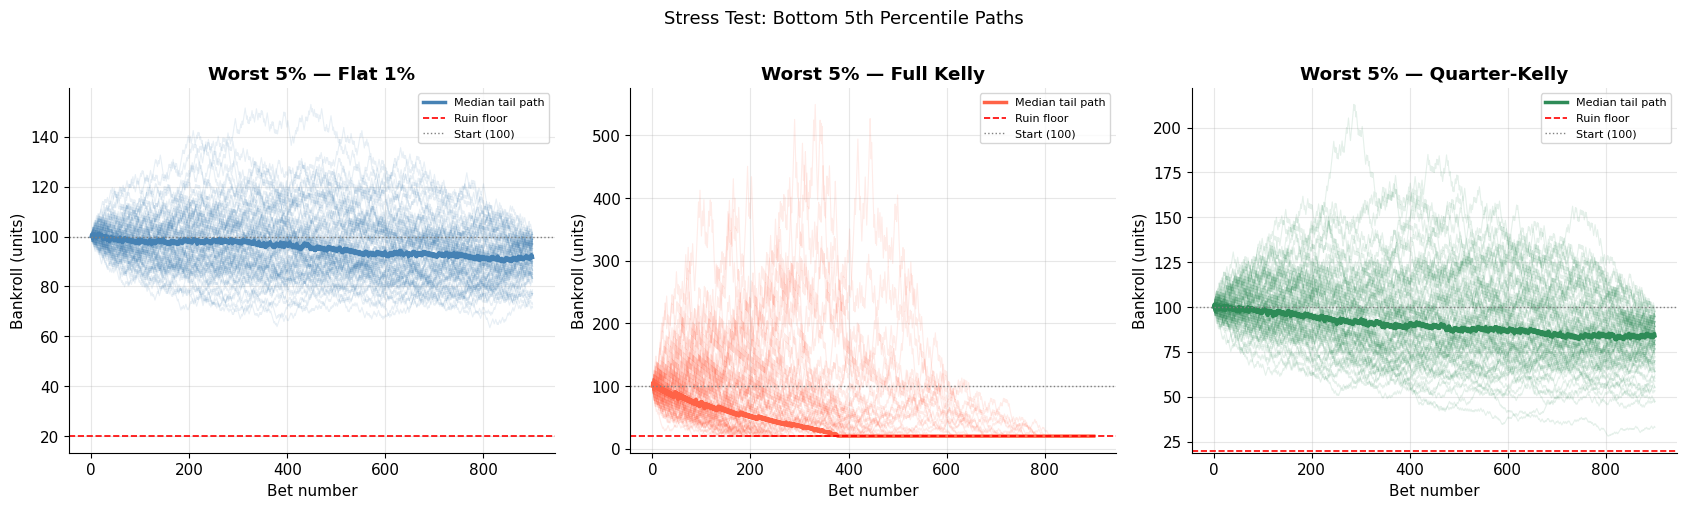

In [7]:
def stress_test(paths, label, color, pct_cutoff=5):
    final_br = paths[:, -1]
    cutoff   = np.percentile(final_br, pct_cutoff)
    tail_idx = np.where(final_br <= cutoff)[0]
    tail_paths = paths[tail_idx]

    # Metrics for this tail
    mdd_tail   = max_drawdown_paths(tail_paths)
    first_ruin = []
    ruin_level = STARTING_BR * RUIN_THRESHOLD
    for path in tail_paths:
        hit = np.where(path <= ruin_level)[0]
        first_ruin.append(hit[0] if len(hit) else N_BETS + 1)

    print(f"\n{'─'*60}")
    print(f" {label} — bottom {pct_cutoff}% ({len(tail_idx)} paths)")
    print(f"  Final BR range    : {final_br[tail_idx].min():.1f} – {final_br[tail_idx].max():.1f} units")
    print(f"  Mean max drawdown : {mdd_tail.mean()*100:.1f}%")
    print(f"  Median MDD        : {np.median(mdd_tail)*100:.1f}%")
    ruin_hit  = sum(r <= N_BETS for r in first_ruin)
    print(f"  % paths hit ruin  : {ruin_hit/len(tail_idx)*100:.1f}%")
    if ruin_hit > 0:
        times = [r for r in first_ruin if r <= N_BETS]
        print(f"  Median bet-to-ruin: {int(np.median(times))}")
    return tail_paths

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=False)
bet_axis   = np.arange(N_BETS + 1)

for ax, (paths, label, color) in zip(axes, [
    (paths_flat, "Flat 1%",      "steelblue"),
    (paths_full, "Full Kelly",   "tomato"),
    (paths_qk,   "Quarter-Kelly","seagreen"),
]):
    tail_paths = stress_test(paths, label, color)
    for path in tail_paths[:80]:
        ax.plot(bet_axis, path, color=color, alpha=0.12, lw=0.8)
    p50 = np.median(tail_paths, axis=0)
    ax.plot(bet_axis, p50, color=color, lw=2.5, label="Median tail path")
    ax.axhline(STARTING_BR * RUIN_THRESHOLD, color="red", lw=1.2, ls="--", label="Ruin floor")
    ax.axhline(STARTING_BR, color="gray", lw=1, ls=":", label="Start (100)")
    ax.set_title(f"Worst 5% — {label}", fontweight="bold")
    ax.set_xlabel("Bet number")
    ax.set_ylabel("Bankroll (units)")
    ax.legend(fontsize=8)

fig.suptitle("Stress Test: Bottom 5th Percentile Paths", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 7. Evaluate Sensitivity to Edge Degradation

What happens if the model's edge slowly erodes? Sweep edge from -2pp (neg EV) to +5pp. Measure median final BR, risk of ruin, and mean max drawdown at each level.

Real system context:
- **NHL shots PLAY** fires at `prob_edge_pp >= 0.02` — the breakeven probe is an important boundary.
- **MLB F5 ML LEAN** at `LEAN_EDGE_MIN = 0.04` — system stacks a 4pp buffer above breakeven.
- A sigma fallback cap (WI-0814) and edge sanity clamp (WI-0815) add protection against false edges.

Sweeping edges … ............................. done


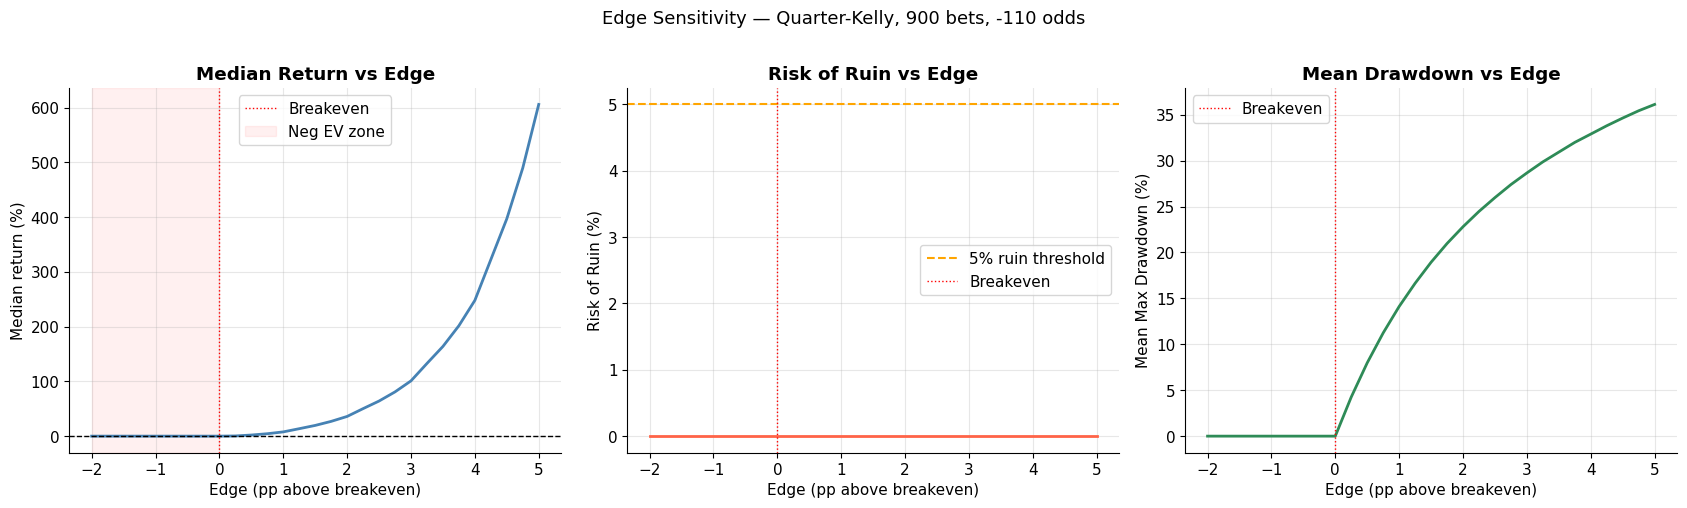


Edge where risk-of-ruin drops ≤5%: -2.00pp
Edge where median return turns positive: 0.25pp

At base edge (+3pp):
 edge_pp  median_return  risk_ruin  mean_mdd
     3.0     100.972664        0.0 28.657298


In [8]:
EDGE_SWEEP = np.linspace(-0.02, 0.05, 29)  # -2pp to +5pp in 0.25pp steps

sensitivity = []
N_SIMS_SWEEP = 3000  # Faster sweep

print("Sweeping edges … ", end="", flush=True)
for edge_pp in EDGE_SWEEP:
    win_p_sweep = BREAKEVEN_P + edge_pp
    win_p_sweep = np.clip(win_p_sweep, 0.01, 0.99)

    # Recalculate Kelly for this edge
    fk_sweep = np.clip((b * win_p_sweep - (1 - win_p_sweep)) / b, 0, 0.5)
    qk_sweep = fk_sweep / 4

    stake_fn = lambda br, s=qk_sweep: br * s if s > 0 else 0.0
    paths_sw  = simulate_bankrolls(win_p_sweep, stake_fn, n_sims=N_SIMS_SWEEP,
                                   seed=99)
    final     = paths_sw[:, -1]
    mdd       = max_drawdown_paths(paths_sw)
    ruin      = empirical_ruin(paths_sw)

    sensitivity.append({
        "edge_pp":       edge_pp * 100,
        "win_p":         win_p_sweep,
        "qkelly_frac":   qk_sweep * 100,
        "median_final":  np.median(final),
        "median_return": (np.median(final) / STARTING_BR - 1) * 100,
        "risk_ruin":     ruin * 100,
        "mean_mdd":      np.mean(mdd) * 100,
    })
    print(".", end="", flush=True)

print(" done")
df_sens = pd.DataFrame(sensitivity)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].plot(df_sens["edge_pp"], df_sens["median_return"], color="steelblue", lw=2)
axes[0].axhline(0, color="black", lw=1, ls="--")
axes[0].axvline(0, color="red", lw=1, ls=":", label="Breakeven")
axes[0].axvspan(-2, 0, color="red", alpha=0.06, label="Neg EV zone")
axes[0].set_xlabel("Edge (pp above breakeven)")
axes[0].set_ylabel("Median return (%)")
axes[0].set_title("Median Return vs Edge", fontweight="bold")
axes[0].legend()

axes[1].plot(df_sens["edge_pp"], df_sens["risk_ruin"], color="tomato", lw=2)
axes[1].axhline(5, color="orange", lw=1.5, ls="--", label="5% ruin threshold")
axes[1].axvline(0, color="red", lw=1, ls=":", label="Breakeven")
axes[1].set_xlabel("Edge (pp above breakeven)")
axes[1].set_ylabel("Risk of Ruin (%)")
axes[1].set_title("Risk of Ruin vs Edge", fontweight="bold")
axes[1].legend()

axes[2].plot(df_sens["edge_pp"], df_sens["mean_mdd"], color="seagreen", lw=2)
axes[2].axvline(0, color="red", lw=1, ls=":", label="Breakeven")
axes[2].set_xlabel("Edge (pp above breakeven)")
axes[2].set_ylabel("Mean Max Drawdown (%)")
axes[2].set_title("Mean Drawdown vs Edge", fontweight="bold")
axes[2].legend()

fig.suptitle("Edge Sensitivity — Quarter-Kelly, 900 bets, -110 odds", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── Critical breakpoints ──────────────────────────────────────────────────────
ruin_cross = df_sens[df_sens["risk_ruin"] <= 5].head(1)
neg_return = df_sens[df_sens["median_return"] <= 0]
print(f"\nEdge where risk-of-ruin drops ≤5%: {ruin_cross['edge_pp'].values[0] if len(ruin_cross) else 'N/A':.2f}pp")
print(f"Edge where median return turns positive: {df_sens[df_sens['median_return']>0].head(1)['edge_pp'].values[0] if len(df_sens[df_sens['median_return']>0]) else 'N/A':.2f}pp")
print(f"\nAt base edge (+3pp):")
row = df_sens[df_sens["edge_pp"].round(2) == 3.0]
if len(row):
    print(row[["edge_pp","median_return","risk_ruin","mean_mdd"]].to_string(index=False))


## 8. Assess Strategy Robustness

Aggregate all metrics and emit a final verdict: **ROBUST** or **FRAGILE**.

╔══════════════════════════════════════════════════════════════╗
║              CHEDDAR-LOGIC BANKROLL RISK SUMMARY             ║
╠══════════════════════════════════════════════════════════════╣
║  Starting bankroll              100 units                     ║
║  Edge (base)                    +3.0pp (55.38% win prob)      ║
║  Market odds                    American -110 | Decimal 1.909 ║
║  Staking (base case)            Quarter-Kelly (1.58% per bet) ║
║  Bets simulated                 900 per path | 10,000 paths   ║
╠──────────────────────────────────────────────────────────────╣
║  ─── Results ───                                             ║
╠──────────────────────────────────────────────────────────────╣
║  Survival rate                  100.0%                        ║
║  Median final bankroll          201.0 units  (+101.0%)        ║
║  Mean final bankroll            225.0 units                   ║
║  5th pct final bankroll         97.6 units                    ║
║  Risk of ruin 

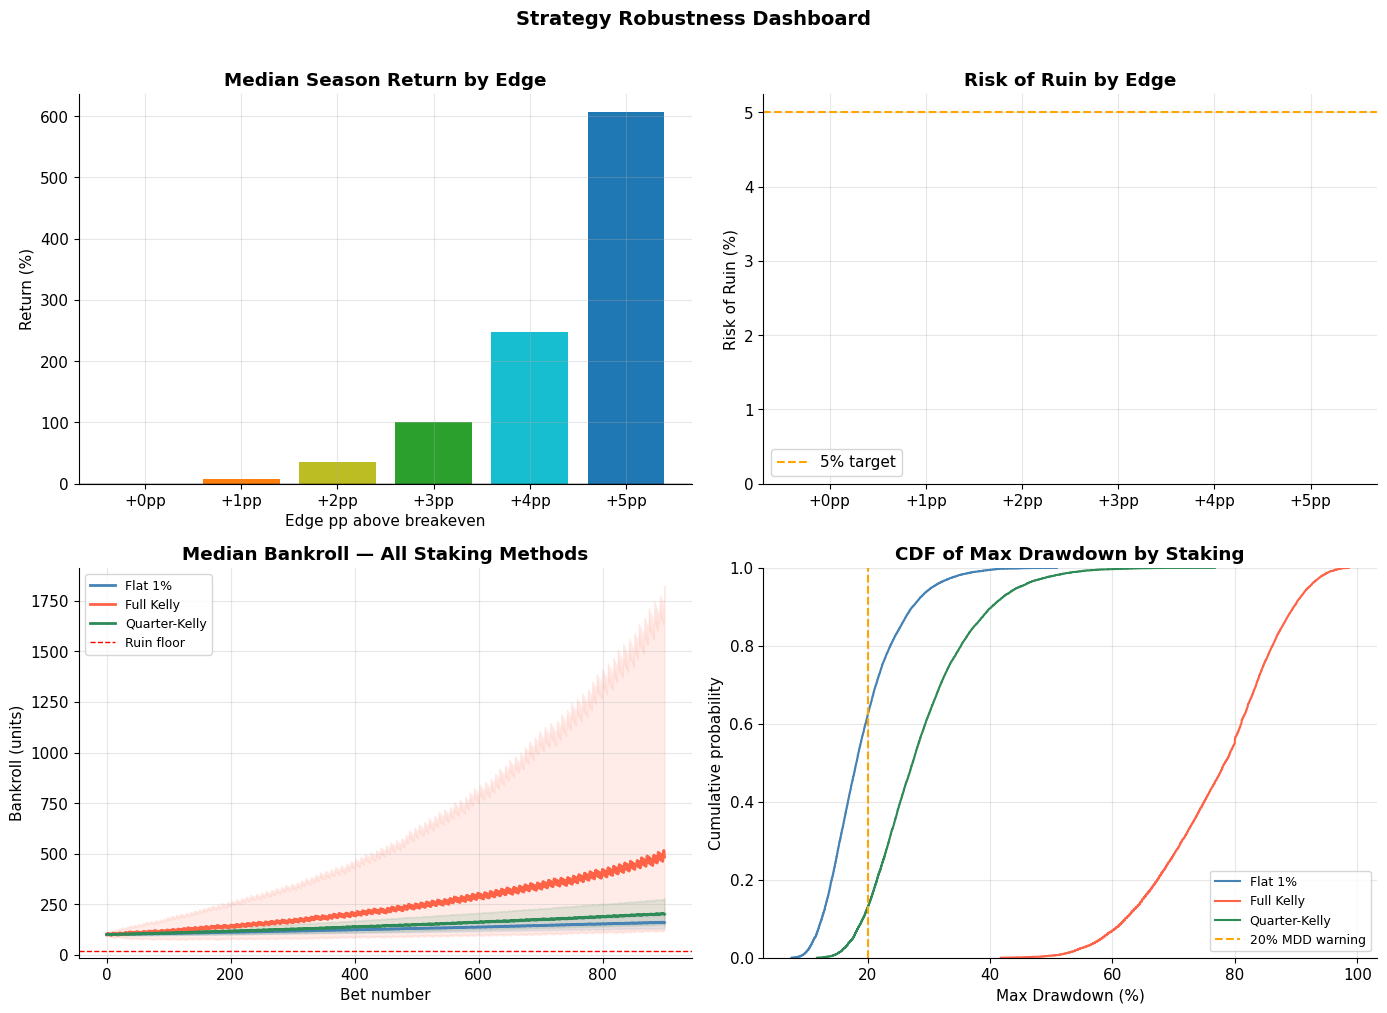



FINAL ANSWER: Strategy ✅ ROBUST
Quarter-Kelly staking survives 900-bet season with 100.0% confidence.
Median return: +101.0% | Risk of ruin: 0.00% | Mean MDD: 28.7%
Edge must stay above ~-2.0pp for ruin < 5%.

Key guard-rails in code that protect the edge floor:
  • NHL shots: prob_edge_pp >= 0.02  (run_nhl_player_shots_model.js:240)
  • MLB F5 ML: LEAN_EDGE_MIN = 0.04   (mlb-model.js:696)
  • Sigma fallback cap: PLAY→LEAN     (WI-0814)
  • Edge sanity clamp + watchdog      (WI-0815)
  • Quarter-Kelly stake fraction      (WI-0819)


In [9]:
import textwrap

# ── Gather metrics (Quarter-Kelly, base +3pp edge) ────────────────────────────
final_qk  = paths_qk[:, -1]
ruin_qk   = results_ruin["Quarter-Kelly"]["empirical_touch"]
mdd_qk_arr = mdd_qk

# Sensitivity: edge drop tolerance before ruin > 5%
ruin5_edge = df_sens[df_sens["risk_ruin"] <= 5]["edge_pp"].min()
ruin5_edge_str = f"{ruin5_edge:.2f}pp" if not np.isnan(ruin5_edge) else "N/A"

# Edge degradation slope (pp per ruin pct increase)
try:
    slope, intercept, r_val, *_ = stats.linregress(
        df_sens["edge_pp"], df_sens["risk_ruin"])
    slope_str = f"{slope:.2f}% ruin / pp edge lost"
except Exception:
    slope_str = "N/A"

summary = {
    "Starting bankroll"         : f"{STARTING_BR:.0f} units",
    "Edge (base)"               : f"+{BASE_EDGE_PP*100:.1f}pp ({BASE_WIN_P*100:.2f}% win prob)",
    "Market odds"               : f"American {AMERICAN_ODDS} | Decimal {DECIMAL_ODDS:.3f}",
    "Staking (base case)"       : f"Quarter-Kelly ({QUARTER_KELLY*100:.2f}% per bet)",
    "Bets simulated"            : f"{N_BETS} per path | {N_SIMS:,} paths",
    "─── Results ───"           : "",
    "Survival rate"             : f"{(1 - ruin_qk)*100:.1f}%",
    "Median final bankroll"     : f"{np.median(final_qk):.1f} units  ({(np.median(final_qk)/STARTING_BR-1)*100:+.1f}%)",
    "Mean final bankroll"       : f"{np.mean(final_qk):.1f} units",
    "5th pct final bankroll"    : f"{np.percentile(final_qk,5):.1f} units",
    "Risk of ruin (touch)"      : f"{ruin_qk*100:.2f}%",
    "Mean max drawdown"         : f"{np.mean(mdd_qk_arr)*100:.1f}%",
    "95th pct max drawdown"     : f"{np.percentile(mdd_qk_arr,95)*100:.1f}%",
    "─── Sensitivity ───"       : "",
    "Ruin ≤5% above edge"       : ruin5_edge_str,
    "Ruin slope vs edge"        : slope_str,
    "Positive return above"     : f"{df_sens[df_sens['median_return']>0]['edge_pp'].min():.2f}pp",
}

# ── Robustness verdict ────────────────────────────────────────────────────────
ROBUST_CRITERIA = {
    "Risk of ruin < 5%"         : ruin_qk < 0.05,
    "Med final BR > start"      : np.median(final_qk) > STARTING_BR,
    "95th pct MDD < 30%"        : np.percentile(mdd_qk_arr, 95) < 0.30,
    "Positive return at +2pp"   : float(df_sens[df_sens["edge_pp"].round(2)==2.0]["median_return"].values[0] if len(df_sens[df_sens["edge_pp"].round(2)==2.0]) else -1) > 0,
    "Ruin stays <5% down to +1pp": float(df_sens[df_sens["edge_pp"].round(2)==round(1.0,2)]["risk_ruin"].values[0] if len(df_sens[df_sens["edge_pp"].round(2)==round(1.0,2)]) else 100) < 5,
}

passed = sum(ROBUST_CRITERIA.values())
total  = len(ROBUST_CRITERIA)
verdict = "✅ ROBUST" if passed >= 4 else ("⚠️  MARGINAL" if passed >= 3 else "❌ FRAGILE")

# ── Print summary table ───────────────────────────────────────────────────────
print("╔" + "═"*62 + "╗")
print("║" + "  CHEDDAR-LOGIC BANKROLL RISK SUMMARY".center(62) + "║")
print("╠" + "═"*62 + "╣")
for k, v in summary.items():
    if v == "":
        print("╠" + "─"*62 + "╣")
        print(f"║  {k:<60}║")
        print("╠" + "─"*62 + "╣")
    else:
        print(f"║  {k:<30} {str(v):<30}║")
print("╠" + "═"*62 + "╣")
print("║" + "  ROBUSTNESS CRITERIA".center(62) + "║")
print("╠" + "─"*62 + "╣")
for crit, ok in ROBUST_CRITERIA.items():
    icon = "✓" if ok else "✗"
    print(f"║  [{icon}] {crit:<56}║")
print("╠" + "═"*62 + "╣")
print(f"║  VERDICT: {verdict:<52}║")
print(f"║  Criteria passed: {passed}/{total}{'':42}║")
print("╚" + "═"*62 + "╝")

# ── Final visual: regime comparison ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

edges_sel = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]
colors_sel = ["#d62728","#ff7f0e","#bcbd22","#2ca02c","#17becf","#1f77b4"]
ax = axes[0, 0]
for ep, col in zip(edges_sel, colors_sel):
    row = df_sens[round(df_sens["edge_pp"], 2) == round(ep, 2)]
    if len(row):
        label_str = f"+{ep:.0f}pp"
        ax.bar(label_str, row["median_return"].values[0], color=col)
ax.axhline(0, color="black", lw=1)
ax.set_title("Median Season Return by Edge", fontweight="bold")
ax.set_ylabel("Return (%)")
ax.set_xlabel("Edge pp above breakeven")

ax = axes[0, 1]
for ep, col in zip(edges_sel, colors_sel):
    row = df_sens[round(df_sens["edge_pp"], 2) == round(ep, 2)]
    if len(row):
        ax.bar(f"+{ep:.0f}pp", row["risk_ruin"].values[0], color=col)
ax.axhline(5, color="orange", lw=1.5, ls="--", label="5% target")
ax.set_title("Risk of Ruin by Edge", fontweight="bold")
ax.set_ylabel("Risk of Ruin (%)")
ax.legend()

ax = axes[1, 0]
bet_ax = np.arange(N_BETS + 1)
for paths, label, color in [
    (paths_flat, "Flat 1%", "steelblue"),
    (paths_full, "Full Kelly", "tomato"),
    (paths_qk,   "Quarter-Kelly", "seagreen"),
]:
    ax.plot(bet_ax, np.median(paths, axis=0), lw=2, label=label, color=color)
    ax.fill_between(bet_ax,
                    np.percentile(paths, 25, axis=0),
                    np.percentile(paths, 75, axis=0), color=color, alpha=0.12)
ax.axhline(STARTING_BR * RUIN_THRESHOLD, color="red", lw=1, ls="--", label="Ruin floor")
ax.set_title("Median Bankroll — All Staking Methods", fontweight="bold")
ax.set_xlabel("Bet number")
ax.set_ylabel("Bankroll (units)")
ax.legend(fontsize=9)

ax = axes[1, 1]
for mdd_arr, label, color in [
    (mdd_flat, "Flat 1%", "steelblue"),
    (mdd_full, "Full Kelly", "tomato"),
    (mdd_qk,   "Quarter-Kelly", "seagreen"),
]:
    ax.ecdf(mdd_arr * 100, label=label, color=color)
ax.axvline(20, color="orange", lw=1.5, ls="--", label="20% MDD warning")
ax.set_title("CDF of Max Drawdown by Staking", fontweight="bold")
ax.set_xlabel("Max Drawdown (%)")
ax.set_ylabel("Cumulative probability")
ax.legend(fontsize=9)

fig.suptitle("Strategy Robustness Dashboard", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(f"\n\nFINAL ANSWER: Strategy {verdict}")
print(f"Quarter-Kelly staking survives {N_BETS}-bet season with {(1-ruin_qk)*100:.1f}% confidence.")
print(f"Median return: {(np.median(final_qk)/STARTING_BR-1)*100:+.1f}% | "
      f"Risk of ruin: {ruin_qk*100:.2f}% | "
      f"Mean MDD: {np.mean(mdd_qk_arr)*100:.1f}%")
print(f"Edge must stay above ~{df_sens[df_sens['risk_ruin']<=5]['edge_pp'].min():.1f}pp for ruin < 5%.")
print(f"\nKey guard-rails in code that protect the edge floor:")
print("  • NHL shots: prob_edge_pp >= 0.02  (run_nhl_player_shots_model.js:240)")
print("  • MLB F5 ML: LEAN_EDGE_MIN = 0.04   (mlb-model.js:696)")
print("  • Sigma fallback cap: PLAY→LEAN     (WI-0814)")
print("  • Edge sanity clamp + watchdog      (WI-0815)")
print("  • Quarter-Kelly stake fraction      (WI-0819)")
